### **[Reverse-Engineering Hamiltonian Monte Carlo: The MCMC Engine Behind Modern Bayesian Inference](https://pub.towardsai.net/reverse-engineering-hamiltonian-monte-carlo-the-mcmc-engine-behind-modern-bayesian-inference-e1d6b54a8c79)**

In [1]:
!pip install -qq --no-deps pymc arviz

In [2]:
import sys

import sqlite3
import requests

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from scipy import stats
from sklearn.preprocessing import StandardScaler

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)
pd.set_option("mode.chained_assignment", None)

az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89  # sets default credible interval used by arviz

%config Inline.figure_format = 'retina'

In [3]:
print("Generating our test data... \n\n")

# test data
real = stats.multivariate_normal([0, 0], np.identity(2))
x, y = real.rvs(50).T

print(f"x (len = {len(x)}): {x}, \n\n y (len = {len(y)}): {y}")

Generating our test data... 


x (len = 50): [ 0.497  0.648 -0.234  1.579 -0.469 -0.463  0.242 -1.725 -1.013 -0.908
  1.466  0.068 -0.544 -1.151 -0.601 -0.602 -0.013  0.823  0.209 -1.328
  0.738 -0.116 -1.479 -0.461  0.344  0.324 -0.677  1.031 -0.839  0.331
 -0.479 -1.106  0.813 -0.072  0.362  0.361 -0.036 -2.62   0.087  0.092
 -0.22   1.478 -0.808  0.915 -0.53   0.097 -0.702 -0.392  0.296  0.005], 

 y (len = 50): [-0.138  1.523 -0.234  0.767  0.543 -0.466 -1.913 -0.562  0.314 -1.412
 -0.226 -1.425  0.111  0.376 -0.292  1.852 -1.058 -1.221 -1.96   0.197
  0.171 -0.301 -0.72   1.057 -1.763 -0.385  0.612  0.931 -0.309  0.976
 -0.186 -1.196  1.356  1.004 -0.645  1.538  1.565  0.822 -0.299 -1.988
  0.357 -0.518 -0.502  0.329  0.513  0.969 -0.328 -1.464  0.261 -0.235]


In [4]:
# The Negative Log-Probability
def calc_U(q, x, y, a=0, b=0.5, k=0, d=0.5):
  mu_y, mu_x = q
  U = (
    np.sum(stats.norm.logpdf(y, loc=mu_y, scale=1)) # likelihood
    + np.sum(stats.norm.logpdf(x, loc=mu_x, scale=1)) # likelihood
    + stats.norm.logpdf(mu_y, loc=a, scale=b) # prior
    + stats.norm.logpdf(mu_x, loc=k, scale=d) # prior
  )
  return -U

In [5]:
#######################
### DATA EXTRACTION ###
#######################
import os
db_link = "https://raw.githubusercontent.com/vanislekahuna/wps-labs/main/data/historical_bc_wildfires/bc_wildfires.db"
response = requests.get(db_link)
with open("bc_wildfires.db", "wb") as f:
    f.write(response.content)

conn = sqlite3.connect('bc_wildfires.db')
cursor = conn.cursor()

join_query = """
WITH weather AS (
    SELECT wind_speed_ms, wind_direction_deg, wind_direction, temperature_c AS temp_c_ign_date, humidity_dewpoint_temperature_2m AS humidity_dewpoint_temp_k_ign_date, soil_temperature_level_1 AS soil_temp_lvl1_ign_date, fire_label AS weather_fire_label
    FROM weather_data
),
terraclimate AS (
    SELECT monthly_mean_temp_c, monthly_total_precip_mm, monthly_mean_humidity_vpd_kPa, monthly_mean_soil_moisture_mm, fire_label AS terraclimate_fire_label
    FROM terraclimate_bc_weather
)
SELECT *
FROM historical_bc_wildfires
LEFT JOIN weather ON historical_bc_wildfires.FIRELABEL = weather.weather_fire_label
LEFT JOIN terraclimate ON historical_bc_wildfires.FIRELABEL = terraclimate.terraclimate_fire_label
WHERE historical_bc_wildfires.SIZE_HA IS NOT NULL
AND historical_bc_wildfires.SIZE_HA > 0
AND historical_bc_wildfires.FIRELABEL NOT IN ('1951-R00037', '1951-R00050', '1951-R00060', '1951-R00067', '1951-R00069', '1951-R00070', '1956-R00107', '1958-V00283', '1956-R00160', '1968-R00088', '1985-V70083', '1985-V70088', '1987-V90016', '1990-V50012');
"""

df = pd.read_sql_query(join_query, conn)
wildfire_df = df[
  [
    "FRCNTR",
    "FIRELABEL",
    "IGN_DATE",
    "FIRE_CAUSE",
    "SIZE_HA",
    "wind_speed_ms",
    "temp_c_ign_date",
    "humidity_dewpoint_temp_k_ign_date",
    "soil_temp_lvl1_ign_date",
    "monthly_mean_temp_c",
    "monthly_total_precip_mm",
    "monthly_mean_humidity_vpd_kPa",
    "monthly_mean_soil_moisture_mm"
  ]
].copy()
print(f"wildfire_df shape: {wildfire_df.shape}\n")

wildfire_df shape: (162905, 13)



In [6]:
###########################
### DATA TRANSFORMATION ###
###########################
centres = wildfire_df["FRCNTR"].unique()

wildfire_df["size_log1ptransformed"] = np.log1p(wildfire_df["SIZE_HA"])
wildfire_df["wind_speed_log1ptransformed"] = np.log1p(wildfire_df["wind_speed_ms"])
wildfire_df["soil_temp_c_lvl1_ign_date"] = wildfire_df["soil_temp_lvl1_ign_date"] - 273.15

one_hot_encodding = pd.get_dummies(wildfire_df["FIRE_CAUSE"], dtype=int)

wildfire_df = pd.concat([wildfire_df, one_hot_encodding], axis=1)

large_fire_df = wildfire_df[wildfire_df['SIZE_HA'] >= 100].dropna()

print(f"\n large_fire_df shape: {large_fire_df.shape} \n")


 large_fire_df shape: (3818, 19) 



In [7]:
###################################
### DATA LOADING/PRE-PROCESSING ###
###################################
continuous_cols = ["wind_speed_log1ptransformed", "temp_c_ign_date",
                    "monthly_total_precip_mm", "monthly_mean_humidity_vpd_kPa"]
X_cont_std = StandardScaler().fit_transform(large_fire_df[continuous_cols])

X_mat = np.column_stack([
  X_cont_std[:, 0],
  large_fire_df["Lightning"].values,
  large_fire_df["Person"].values,
  X_cont_std[:, 1],
  X_cont_std[:, 2],
  X_cont_std[:, 3],
])

zone_labels = sorted(large_fire_df["FRCNTR"].astype(str).unique())
zone_to_idx = {z: i for i, z in enumerate(zone_labels)}
zone_idx = large_fire_df["FRCNTR"].astype(str).map(zone_to_idx).values
print(f"Value count of generated zone labels: \n{pd.Series(zone_idx).value_counts().sort_index()}")

y = large_fire_df["size_log1ptransformed"].values

Value count of generated zone labels: 
0     343
1     406
2    1327
3     591
4     651
5     500
Name: count, dtype: int64


In [8]:
##############################################################
### HIERARCHICAL MULTI-LEVEL BAYESIAN REGRESSION MODELLING ###
##############################################################
coords = {
  "zone": zone_labels,
  "predictor": ["wind_speed", "lightning", "person", "temp", "precip", "vpd"],
  "obs_id": np.arange(len(y)),
}

with pm.Model(coords=coords) as hier_model:
  zone_idx_ = pm.Data("zone_idx", zone_idx, dims="obs_id")
  X = pm.Data("X_mat", X_mat, dims=("obs_id", "predictor"))

  # Population-level (grand mean across zones)
  mu_alpha = pm.Normal("mu_alpha", mu=4.0, sigma=0.5)      # log(100+1) ≈ 4.6, our size floor
  mu_beta  = pm.Normal("mu_beta", mu=0.0, sigma=1.0, dims="predictor")

  # Between-zone SD — magnitude of cross-zone heterogeneity per effect
  sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)
  sigma_beta  = pm.HalfNormal("sigma_beta", sigma=0.5, dims="predictor")

  # Non-centered parameterization
  z_alpha = pm.Normal("z_alpha", 0.0, 1.0, dims="zone")
  z_beta  = pm.Normal("z_beta", 0.0, 1.0, dims=("zone", "predictor"))

  alpha_zone = pm.Deterministic("alpha_zone", mu_alpha + sigma_alpha * z_alpha, dims="zone")
  beta_zone  = pm.Deterministic("beta_zone", mu_beta + sigma_beta * z_beta, dims=("zone", "predictor"))

  mu = alpha_zone[zone_idx_] + (beta_zone[zone_idx_] * X).sum(axis=-1)

  sigma_y = pm.HalfNormal("sigma_y", sigma=0.5)
  y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_y, observed=y, dims="obs_id")

  idata = pm.sample(
    draws=2000,
    tune=2000,
    chains=4,
    target_accept=0.95,   # higher than default — hierarchical funnels need this
    random_seed=42,
    idata_kwargs={"log_likelihood": True},  # needed for LOO below
  )

n_div = idata.sample_stats["diverging"].sum().item()
print(f"Divergences: {n_div}")
az.summary(idata, var_names=["mu_alpha", "mu_beta", "sigma_alpha", "sigma_beta", "sigma_y"])

Output()

Divergences: 0


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,5.619,0.316,5.136,6.084,0.006,0.005,3191.0,4539.0,1.0
mu_beta[wind_speed],0.011,0.058,-0.074,0.093,0.001,0.002,4272.0,3963.0,1.0
mu_beta[lightning],0.602,0.174,0.337,0.878,0.002,0.003,5432.0,5526.0,1.0
mu_beta[person],0.067,0.116,-0.127,0.238,0.001,0.002,8065.0,5421.0,1.0
mu_beta[temp],0.004,0.044,-0.060,0.069,0.001,0.001,6615.0,4902.0,1.0
mu_beta[precip],-0.107,0.040,-0.164,-0.044,0.001,0.001,6599.0,4260.0,1.0
mu_beta[vpd],0.295,0.061,0.210,0.394,0.001,0.001,5417.0,4780.0,1.0
sigma_alpha,0.553,0.238,0.224,0.907,0.004,0.003,3582.0,5259.0,1.0
sigma_beta[wind_speed],0.102,0.072,0.000,0.181,0.001,0.002,2303.0,2901.0,1.0
sigma_beta[lightning],0.317,0.143,0.113,0.519,0.002,0.002,4364.0,3612.0,1.0


Text(0.5, 1.0, 'Zone-level Heterogeneity: Population-level average effect (89% HDI)')

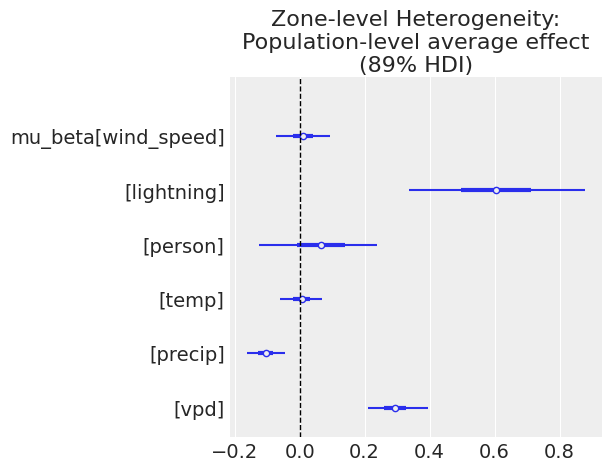

In [9]:
# ZONE-LEVEL HETEROGENEITY:
# Population-level average effect (across all zones)
az.plot_forest(idata, var_names=["mu_beta"], combined=True, hdi_prob=0.89)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Zone-level Heterogeneity: Population-level average effect (89% HDI)")

Text(0.5, 0.98, 'Zone-level Heterogeneity: Zone-specific Coefficients, partially pooled (89% HDI)')

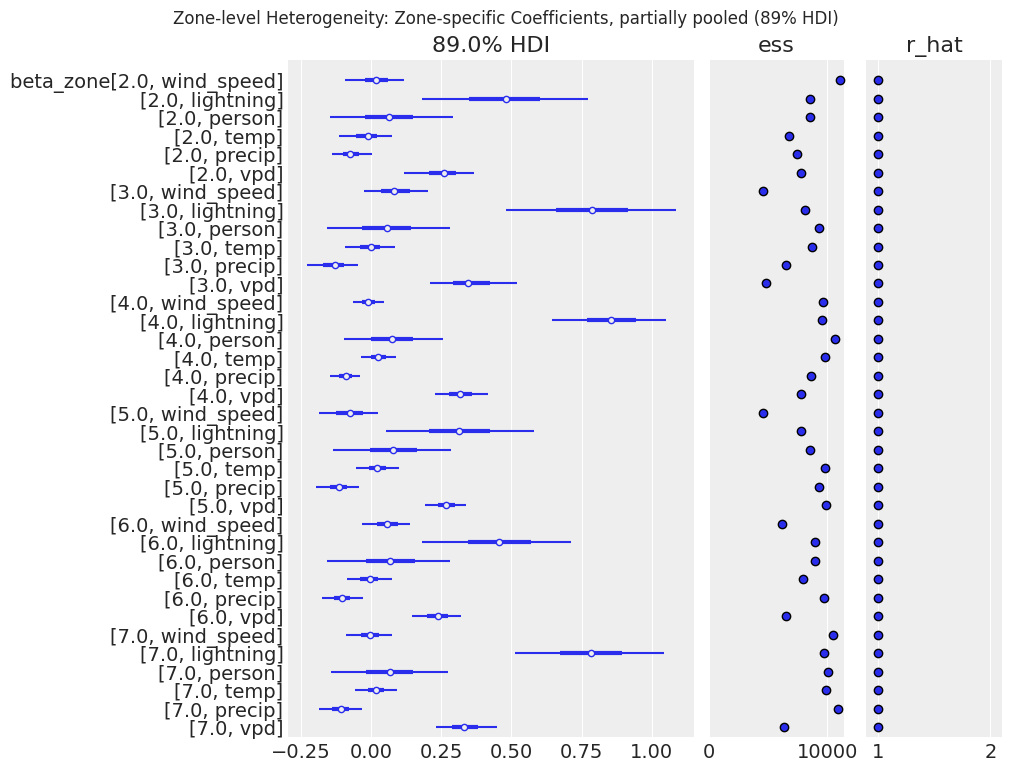

In [10]:
# ZONE-LEVEL HETEROGENEITY:
# Zone-specific coefficients, partially pooled
az.plot_forest(idata, var_names=["beta_zone"], combined=True, r_hat=True, ess=True)
plt.gcf().suptitle("Zone-level Heterogeneity: Zone-specific Coefficients, partially pooled (89% HDI)")

In [11]:
#################################################################
### PREDICTIVE PERFORMANCE: Bayesian R² & Model Comparison ###
#################################################################

# 1. Generate posterior predictive samples (needed for R²)
with hier_model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=42)

# 2. Bayesian R² (Gelman et al. 2019 formulation)
# Now that idata contains 'posterior_predictive', we can extract y_obs
y_pred_samples = idata.posterior_predictive["y_obs"].values.reshape(-1, len(y))
bayes_r2 = az.r2_score(y, y_pred_samples)
print(f"Bayesian R²: {bayes_r2}")

# 3. LOO (Leave-One-Out Cross-Validation)
loo = az.loo(idata, pointwise=True)
print("\nLeave-One-Out Cross-Validation:")
print(loo)

high_k = (loo.pareto_k.values > 0.7).sum()
print(f"\nObservations with unreliable LOO estimates (k > 0.7): {high_k}")

Output()

Bayesian R²: r2        0.368
r2_std    0.006
dtype: float64

Leave-One-Out Cross-Validation:
Computed from 8000 posterior samples and 3818 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -6658.65    51.09
p_loo       26.64        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3818  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Observations with unreliable LOO estimates (k > 0.7): 0


In [12]:
def unpack_params(q, J, P):
  """
  Slice a flat parameter vector q into its named pieces. This mirrors
  what PyTensor does internally inside PyMC -- every model, no matter
  how many groups or predictors it has, ultimately reduces to one long
  vector that the sampler walks through.
  """
  idx = 0
  mu_alpha    = q[idx]; idx += 1
  mu_beta     = q[idx:idx+P]; idx += P
  sigma_alpha = q[idx]; idx += 1
  sigma_beta  = q[idx:idx+P]; idx += P
  z_alpha     = q[idx:idx+J]; idx += J
  z_beta      = q[idx:idx+J*P].reshape(J, P); idx += J*P
  sigma_y     = q[idx]; idx += 1
  return mu_alpha, mu_beta, sigma_alpha, sigma_beta, z_alpha, z_beta, sigma_y


def hierarchical_calc_U(q, X, y, zone_idx, J, P,
          mu_alpha_prior=(4.0, 0.5), mu_beta_prior=(0.0, 1.0),
          sigma_alpha_prior=0.5, sigma_beta_prior=0.5, sigma_y_prior=0.5):
  """Negative log-posterior (potential energy) at a single point q."""
  mu_alpha, mu_beta, sigma_alpha, sigma_beta, z_alpha, z_beta, sigma_y = unpack_params(q, J, P)

  # HalfNormal parameters have zero density outside their support.
  # Real NUTS avoids this entirely by sampling on a log-transformed, constrained scale internally.
  # We stay on the natural scale here.
  if sigma_alpha <= 0 or np.any(sigma_beta <= 0) or sigma_y <= 0:
    return np.inf

  # Non-centered transform (matches the pm.Deterministic lines)
  alpha_zone = mu_alpha + sigma_alpha * z_alpha
  beta_zone  = mu_beta + sigma_beta * z_beta

  # Linear predictor
  mu = alpha_zone[zone_idx] + np.sum(beta_zone[zone_idx] * X, axis=-1)

  log_lik = np.sum(stats.norm.logpdf(y, loc=mu, scale=sigma_y))

  log_prior = (
    stats.norm.logpdf(mu_alpha, *mu_alpha_prior)
    + np.sum(stats.norm.logpdf(mu_beta, *mu_beta_prior)) # one sum per predictor - 6 predictors (6 parameters)
    + stats.halfnorm.logpdf(sigma_alpha, scale=sigma_alpha_prior)
    + np.sum(stats.halfnorm.logpdf(sigma_beta, scale=sigma_beta_prior)) # one sum per predictor - 6 predictors (6 parameters)
    + np.sum(stats.norm.logpdf(z_alpha, 0.0, 1.0)) # one sum per zone - 6 zones (6 parameters)
    + np.sum(stats.norm.logpdf(z_beta, 0.0, 1.0)) # one sum per zone per predictor - 6 zones x 6 predictors (36 parameters)
    + stats.halfnorm.logpdf(sigma_y, scale=sigma_y_prior)
  )

  return -(log_lik + log_prior)

In [13]:
# Gradient of the Negative Log-Probability
def calc_U_gradient(q, x, y, a=0, b=0.5, k=0, d=0.5):
  mu_y, mu_x = q

  G1 = np.sum(y - mu_y) + (a - mu_y) / b**2  # dU/dmuy
  G2 = np.sum(x - mu_x) + (k - mu_x) / d**2  # dU/dmux

  return np.array([-G1, -G2])

In [14]:
def hamiltonian_monte_carlo(U, grad_U, epsilon, L, current_q, *args):
  q = current_q.copy()
  p = np.random.normal(loc=0, scale=1, size=len(q))  # random flick - p is momentum
  current_p = p.copy()

  # Make a half step for momentum at the beginning
  p -= epsilon * grad_U(q, *args) / 2

  # initialize bookkeeping - saves trajectory
  qtraj = np.full((L + 1, len(q)), np.nan)
  ptraj = qtraj.copy()
  qtraj[0, :] = current_q
  ptraj[0, :] = p

  # Code 9.9 starts here
  # Alternate full steps for position and momentum
  for i in range(L):
    q += epsilon * p  # Full step for the position
    qtraj[i + 1, :] = q

    # Make a full step for the momentum, except at the end of trajectory
    if i != L - 1:
      p -= epsilon * grad_U(q, *args)
      ptraj[i + 1, :] = p

  # Make a half step for momentum at the end
  p -= epsilon * grad_U(q, *args) / 2
  ptraj[L, :] = p

  # Negate momentum at end of trajectory to make the proposal symmetric
  p *= -1

  # Evaluate potential and kinetic energies at start and end of trajectory
  current_U = U(current_q, *args)
  current_K = np.sum(current_p**2) / 2
  proposed_U = U(q, *args)
  proposed_K = np.sum(p**2) / 2

  # Accept or reject the state at end of trajectory, returning either
  # the position at the end of the trajectory or the initial position
  accept = False

  if np.random.uniform() < np.exp(current_U - proposed_U + current_K - proposed_K):
    new_q = q  # accept
    accept = True
  else:
    new_q = current_q  # reject

  return dict(q=new_q, traj=qtraj, ptraj=ptraj, accept=accept)

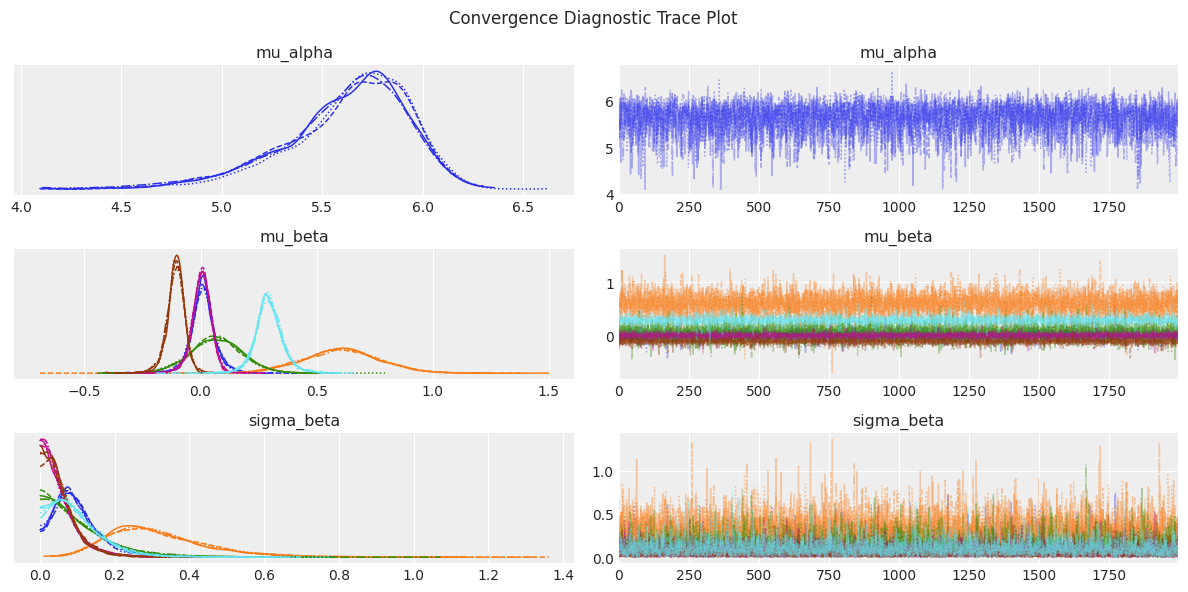

In [15]:
az.plot_trace(idata, var_names=["mu_alpha", "mu_beta", "sigma_beta"], compact=True)
plt.gcf().suptitle("Convergence Diagnostic Trace Plot")
plt.tight_layout()